## Tensorflow Custom Data Pipeline for Heavy Image datasets

Solution to the problems mentioned in this notebook: [Kaggle notebook for standard Tesnorflow data pipeline](https://www.kaggle.com/code/mohanarc/tensorflow-data-pipeline-demo)  

Feel free to run this notebook in one go.


In [1]:
!pip install imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 70.1 MB/s eta 0:00:00:00:0100:01


In [2]:
import warnings
from pathlib import Path

# Declare the paths
DATA_DIR = Path("/kaggle/input/competitions/vesuvius-challenge-surface-detection")
TRAIN_IMAGES_DIR = Path("/kaggle/input/competitions/vesuvius-challenge-surface-detection/train_images")
TRAIN_LABELS_DIR = Path("/kaggle/input/competitions/vesuvius-challenge-surface-detection/train_labels")
MODEL_INPUT_SIZE = (256, 256, 256)  # (depth, height, width) - standarize volume size to this
# For training


In [3]:
import tensorflow as tf
import os
import tifffile as tiff
import numpy as np

class SurfaceDataModuleTF:
    def __init__(self, images_dir, labels_dir, volume_shape=(256, 256, 256), batch_size=1):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.volume_shape = volume_shape
        self.batch_size = batch_size
        self.filenames = sorted([f for f in os.listdir(images_dir) if f.endswith('.tif')])

    def _resize_3d(self, volume):
        """Native TF 3D resize logic"""
        # Resizing 3D volumes by 2D slices (D, H, W) -> (256, 256, 256)
        volume = tf.expand_dims(volume, -1) # (D, H, W, 1)
        # 1. Resize H, W
        volume = tf.image.resize(volume, [self.volume_shape[1], self.volume_shape[2]])
        # 2. Transpose to resize D
        volume = tf.transpose(volume, perm=[1, 0, 2, 3]) # (H, D, W, 1)
        volume = tf.image.resize(volume, [self.volume_shape[0], self.volume_shape[2]])
        volume = tf.transpose(volume, perm=[1, 0, 2, 3]) # (D, H, W, 1)
        return tf.squeeze(volume, -1)

    def _load_and_process(self, filename):
        """Loads TIF and resizes on the fly"""
        # Use py_function to bridge TiffFile into the TF graph
        def read_tiff(f):
            img = tiff.imread(os.path.join(self.images_dir, f.numpy().decode()))
            return img.astype(np.float32) / 255.0
            
        # Wrap the Python function
        vol = tf.py_function(read_tiff, [filename], tf.float32)
        vol.set_shape([None, 320, 320]) # Assume original dimensions
        
        # Apply 3D resize
        vol = self._resize_3d(vol)
        return vol

    def get_dataset(self):
        ds = tf.data.Dataset.from_tensor_slices(self.filenames)
        ds = ds.map(self._load_and_process, num_parallel_calls=tf.data.AUTOTUNE)
        
        # Disk Caching: Prevents crashes by offloading to local storage
        ds = ds.cache('/tmp/vesuvius_cache')
        ds = ds.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return ds

# Usage
dm = SurfaceDataModuleTF(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)
train_ds = dm.get_dataset()

2026-03-12 10:34:55.624422: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773311695.797719      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773311695.845516      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773311696.293110      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773311696.293146      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773311696.293148      55 computation_placer.cc:177] computation placer alr

In [4]:
train_ds

<_PrefetchDataset element_spec=TensorSpec(shape=(None, 256, 256, 256), dtype=tf.float32, name=None)>

Data type: <class 'tensorflow.python.framework.ops.EagerTensor'>


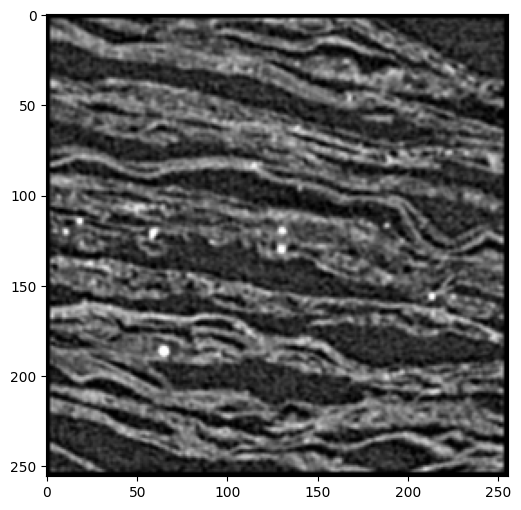

In [6]:
for data in train_ds.take(1):  ## Visualize
    print(f"Data type: {type(data)}") #data tye
    vol = data[0] if isinstance(data, (tuple, list)) else data  ### access the tensor
    slice_to_plot = vol[0, 0, :, :].numpy() ## get a slice from the 3D volume    
    plt.figure(figsize=(6, 6))
    plt.imshow(slice_to_plot, cmap="gray")
    plt.show()